# Spotify 2024 Global Streaming — Data Analytics Demo

**Topics Covered:**
1. Loading data from CSV and JSON
2. Cleaning messy data
3. Merging DataFrames
4. Exploratory Data Analysis (EDA) best practices
5. Visualizing data with 8 plot types

**Dataset:** Spotify 2024 Global Streaming Data  
**Files:** `spotify_tracks_info.csv` + `spotify_streaming_metrics.json`

---
## Step 0: Setup — Import Libraries

In [25]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns


---
## Step 1: Load the Data

We have **two separate files** that together make a complete picture:
- `spotify_tracks_info.csv` — track catalog (artist, album, genre, etc.)
- `spotify_streaming_metrics.json` — performance numbers (streams, skip rate, etc.)

Real-world data almost never comes in one clean file!

In [26]:
# Load the CSV
tracks_df = pd.read_csv('../data/spotify_tracks_info.csv')

print('Shape:', tracks_df.shape)
tracks_df.head()

Shape: (506, 6)


,country,Artist,album,Genre,release_year,Platform Type
0,germany,Taylor Swift,1989 (Taylor's Version),NaN,2020,Free
1,Brazil,The Weeknd,After Hours,R&B,2023,Premium
2,United States,Post Malone,Austin,Reggaeton,2019,Free
3,Italy,Ed Sheeran,Autumn Variations,K-pop,2019,Premium
4,Italy,Ed Sheeran,Autumn Variations,R&B,2019,Free


In [27]:
# Load the JSON
with open('../data/spotify_streaming_metrics.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

metrics_df = pd.DataFrame(data)

print('Shape:', metrics_df.shape)
metrics_df.head()

Shape: (500, 9)


,country,artist,album,monthly_listeners_millions,total_streams_millions,total_hours_streamed_millions,avg_stream_duration_min,streams_last_30_days_millions,skip_rate_pct
0,GERMANY,Taylor Swift,1989 (Taylor's Version),23.1,3695.53,14240.35,4.28,118.51,NaN
1,Brazil,The Weeknd,After Hours,60.6,2828.16,11120.44,3.90,44.87,23.98
2,United States,Post Malone,Austin,42.84,1425.46,4177.49,4.03,19.46,4.77
3,Italy,Ed Sheeran,Autumn Variations,73.24,2704.33,12024.08,3.26,166.05,25.12
4,Italy,Ed Sheeran,Autumn Variations,7.89,3323.25,13446.32,4.47,173.43,15.82


---
## Step 2: First Look at Each DataFrame

**EDA Best Practice #1:** Before touching anything, just *look*. Run `.info()`, `.describe()`, and `.head()` on every new dataset.

In [28]:
print('=== tracks_df ===')
tracks_df.info()

=== tracks_df ===
<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   country        506 non-null    str  
 1   Artist         506 non-null    str  
 2   album          506 non-null    str  
 3   Genre          456 non-null    str  
 4   release_year   506 non-null    int64
 5   Platform Type  506 non-null    str  
dtypes: int64(1), str(5)
memory usage: 23.8 KB


In [29]:
print('=== metrics_df ===')
metrics_df.info()

=== metrics_df ===
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   country                        500 non-null    str    
 1   artist                         500 non-null    str    
 2   album                          500 non-null    str    
 3   monthly_listeners_millions     500 non-null    object 
 4   total_streams_millions         500 non-null    float64
 5   total_hours_streamed_millions  500 non-null    float64
 6   avg_stream_duration_min        500 non-null    float64
 7   streams_last_30_days_millions  500 non-null    float64
 8   skip_rate_pct                  454 non-null    float64
dtypes: float64(5), object(1), str(3)
memory usage: 35.3+ KB


### What problems do you notice?

Take a moment to look at the output above. Can you spot:

1. **Column naming** — are they consistent between the two files?
2. **Data types** — is `monthly_listeners_millions` the right type?
3. **Missing values** — which columns have them?

Write your observations here before moving on.

---
## Step 3: Cleaning `tracks_df` (the CSV)

**EDA Best Practice #2:** Fix column names, data types, whitespace, and nulls *before* doing any analysis.

In [30]:
# See the current column names
print('tracks_df columns:', tracks_df.columns.tolist())
print()
print('metrics_df columns:', metrics_df.columns.tolist())

tracks_df columns: ['country', 'Artist', 'album', 'Genre', 'release_year', 'Platform Type']

metrics_df columns: ['country', 'artist', 'album', 'monthly_listeners_millions', 'total_streams_millions', 'total_hours_streamed_millions', 'avg_stream_duration_min', 'streams_last_30_days_millions', 'skip_rate_pct']


In [31]:
# Standardize all column names: lowercase and replace spaces with underscores
tracks_df.columns = tracks_df.columns.str.lower().str.replace(' ', '_')

print('Fixed columns:', tracks_df.columns.tolist())

Fixed columns: ['country', 'artist', 'album', 'genre', 'release_year', 'platform_type']


In [32]:
# EDA Best Practice #3: Check for duplicate rows
print('Duplicate rows:', tracks_df.duplicated().sum())
tracks_df[tracks_df.duplicated(keep=False)].sort_values('artist').head(12)

Duplicate rows: 24


,country,artist,album,genre,release_year,platform_type
223,Brazil,Ariana Grande,Eternal Sunshine,Indie,2020,Premium
57,Brazil,Ariana Grande,Eternal Sunshine,Indie,2020,Premium
230,United States,BLACKPINK,BORN PINK,NaN,2021,Free
50,United States,BLACKPINK,BORN PINK,NaN,2021,Free
249,South Africa,BTS,Proof,Reggaeton,2023,Free
170,India,BTS,Proof,NaN,2023,Free
163,South Africa,BTS,Proof,Reggaeton,2023,Free
342,Indonesia,BTS,Proof,Classical,2023,Free
411,Indonesia,BTS,Proof,Classical,2023,Free
470,India,BTS,Proof,NaN,2023,Free


In [33]:
# Drop duplicates
tracks_df = tracks_df.drop_duplicates()
print('Rows after removing duplicates:', len(tracks_df))

Rows after removing duplicates: 482


In [34]:
# EDA Best Practice #4: Understand your missing values
print('Missing values in tracks_df:')
print(tracks_df.isnull().sum())
print()
print('% missing:')
print(round(tracks_df.isnull().mean() * 100, 1))

Missing values in tracks_df:
country           0
artist            0
album             0
genre            47
release_year      0
platform_type     0
dtype: int64

% missing:
country          0.0
artist           0.0
album            0.0
genre            9.8
release_year     0.0
platform_type    0.0
dtype: float64


In [35]:
# Fill missing Genre with 'Unknown'
tracks_df['genre'] = tracks_df['genre'].fillna('Unknown')

print('Nulls remaining:', tracks_df.isnull().sum().sum())

Nulls remaining: 0


In [36]:
# EDA Best Practice #5: Strip hidden whitespace from string columns
# This is a very common bug that breaks merges!

# First, let's see the problem
print('Sample artist values (notice leading spaces):')
print(tracks_df['artist'].head(15).tolist())

Sample artist values (notice leading spaces):
['  Taylor Swift', 'The Weeknd', 'Post Malone', 'Ed Sheeran', 'Ed Sheeran', 'Billie Eilish', 'Bad Bunny', 'Doja Cat', 'Bad Bunny', 'Ariana Grande', 'Dua Lipa', 'BLACKPINK', '  Doja Cat', 'SZA', 'Post Malone']


In [37]:
# Strip whitespace from all string (object) columns
str_cols = tracks_df.select_dtypes(include='object').columns
for col in str_cols:
    tracks_df[col] = tracks_df[col].str.strip()

# Also standardize country to Title Case
tracks_df['country'] = tracks_df['country'].str.title()

print('Sample artist values after strip:')
print(tracks_df['artist'].head(15).tolist())

Sample artist values after strip:
['Taylor Swift', 'The Weeknd', 'Post Malone', 'Ed Sheeran', 'Ed Sheeran', 'Billie Eilish', 'Bad Bunny', 'Doja Cat', 'Bad Bunny', 'Ariana Grande', 'Dua Lipa', 'BLACKPINK', 'Doja Cat', 'SZA', 'Post Malone']


C:\Users\trerr\AppData\Local\Temp\ipykernel_35712\570177950.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = tracks_df.select_dtypes(include='object').columns


---
## Step 4: Cleaning `metrics_df` (the JSON)

In [38]:
print('Missing values in metrics_df:')
print(metrics_df.isnull().sum())

Missing values in metrics_df:
country                           0
artist                            0
album                             0
monthly_listeners_millions        0
total_streams_millions            0
total_hours_streamed_millions     0
avg_stream_duration_min           0
streams_last_30_days_millions     0
skip_rate_pct                    46
dtype: int64


In [39]:
# Check the dtype issue with monthly_listeners_millions
print('dtype:', metrics_df['monthly_listeners_millions'].dtype)
print()
print('Sample values:')
print(metrics_df['monthly_listeners_millions'].head(20).tolist())

dtype: object

Sample values:
['23.1', 60.6, 42.84, 73.24, 7.89, 37.65, 27.72, 40.72, 25.42, 75.82, 97.14, 1.32, 20.69, 24.71, 66.32, '99.52', 59.26, 67.23, 66.24, 34.59]


In [40]:
# Convert to numeric — pd.to_numeric handles strings and None
metrics_df['monthly_listeners_millions'] = pd.to_numeric(
    metrics_df['monthly_listeners_millions'], errors='coerce'
)

print('dtype after fix:', metrics_df['monthly_listeners_millions'].dtype)

dtype after fix: float64


In [41]:
metrics_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   country                        500 non-null    str    
 1   artist                         500 non-null    str    
 2   album                          500 non-null    str    
 3   monthly_listeners_millions     500 non-null    float64
 4   total_streams_millions         500 non-null    float64
 5   total_hours_streamed_millions  500 non-null    float64
 6   avg_stream_duration_min        500 non-null    float64
 7   streams_last_30_days_millions  500 non-null    float64
 8   skip_rate_pct                  454 non-null    float64
dtypes: float64(6), str(3)
memory usage: 35.3 KB


In [42]:
# Fill missing skip_rate with the median
median_skip = metrics_df['skip_rate_pct'].median()
print('Median skip rate:', median_skip)

metrics_df['skip_rate_pct'] = metrics_df['skip_rate_pct'].fillna(median_skip)

Median skip rate: 20.854999999999997


In [43]:
# Strip whitespace and standardize country casing
str_cols = metrics_df.select_dtypes(include='object').columns
for col in str_cols:
    metrics_df[col] = metrics_df[col].str.strip()

metrics_df['country'] = metrics_df['country'].str.title()

print('Sample country values:')
print(metrics_df['country'].unique()[:10])

Sample country values:
<StringArray>
[       'Germany',         'Brazil',  'United States',          'Italy',
         'Sweden',         'France', 'United Kingdom',      'Argentina',
    'South Korea',   'South Africa']
Length: 10, dtype: str


C:\Users\trerr\AppData\Local\Temp\ipykernel_35712\2313964249.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = metrics_df.select_dtypes(include='object').columns


---
## Step 5: Merging the DataFrames

Now that both DataFrames are clean, we can combine them.

**Join Keys:** `country`, `artist`, `album` — these three columns identify a unique record in both files.

| Merge Type | What it keeps |
|---|---|
| `inner` | Only rows that match in **both** DataFrames |
| `left` | All rows from the left, matches from the right |
| `outer` | All rows from both, fills NaN where no match |

In [44]:
df = pd.merge(
    tracks_df,
    metrics_df,
    on=['country', 'artist', 'album'],
    how='inner'
)

print('tracks_df rows:    ', len(tracks_df))
print('metrics_df rows:   ', len(metrics_df))
print('Merged df rows:    ', len(df))
df.head()

tracks_df rows:     482
metrics_df rows:    500
Merged df rows:     1282


,country,artist,album,genre,release_year,platform_type,monthly_listeners_millions,total_streams_millions,total_hours_streamed_millions,avg_stream_duration_min,streams_last_30_days_millions,skip_rate_pct
0,Germany,Taylor Swift,1989 (Taylor's Version),Unknown,2020,Free,23.10,3695.53,14240.35,4.28,118.51,20.855
1,Germany,Taylor Swift,1989 (Taylor's Version),Unknown,2020,Free,34.59,4315.28,12934.24,2.88,28.90,8.160
2,Germany,Taylor Swift,1989 (Taylor's Version),Unknown,2020,Free,64.26,3132.91,8225.81,4.17,119.75,20.855
3,Germany,Taylor Swift,1989 (Taylor's Version),Unknown,2020,Free,14.90,3598.44,14189.07,2.71,38.32,37.280
4,Brazil,The Weeknd,After Hours,R&B,2023,Premium,60.60,2828.16,11120.44,3.90,44.87,23.980


In [45]:
# Check for any remaining nulls after merge
print('Nulls in merged df:')
print(df.isnull().sum())
print()
print('Final shape:', df.shape)

Nulls in merged df:
country                          0
artist                           0
album                            0
genre                            0
release_year                     0
platform_type                    0
monthly_listeners_millions       0
total_streams_millions           0
total_hours_streamed_millions    0
avg_stream_duration_min          0
streams_last_30_days_millions    0
skip_rate_pct                    0
dtype: int64

Final shape: (1282, 12)


---
## Step 6: Exploratory Data Analysis (EDA)

### EDA Best Practice Checklist:
1. Shape and column names
2. Data types — do they make sense?
3. Missing values — how many, where, does it matter?
4. **Distributions** of numeric columns
5. **Unique values** of categorical columns
6. **Relationships** between variables
7. **Outliers**

In [46]:
# Summary statistics for all numeric columns
df.describe()

,release_year,monthly_listeners_millions,total_streams_millions,total_hours_streamed_millions,avg_stream_duration_min,streams_last_30_days_millions,skip_rate_pct
count,1282.000000,1282.000000,1282.000000,1282.000000,1282.000000,1282.000000,1282.000000
mean,2020.810452,51.644446,2574.416045,8942.764290,3.527402,99.502192,21.036349
std,1.756651,28.426387,1419.417428,5192.714002,0.562187,56.788373,9.998282
min,2018.000000,1.010000,53.560000,184.300000,2.510000,2.850000,1.160000
25%,2019.000000,28.930000,1317.040000,4362.090000,3.060000,48.830000,13.490000
50%,2021.000000,52.300000,2703.990000,9045.440000,3.560000,101.465000,20.855000
75%,2023.000000,75.300000,3794.390000,12686.130000,3.990000,148.180000,28.737500
max,2023.000000,99.800000,4985.540000,21874.920000,4.490000,200.000000,39.970000


In [47]:
# Unique value counts for categorical columns
cat_cols = ['country', 'artist', 'album', 'genre', 'platform_type']
for col in cat_cols:
    print(f'{col}: {df[col].nunique()} unique values')
    print(df[col].value_counts().head(5))
    print()

country: 20 unique values
country
South Korea     96
South Africa    96
Italy           91
Russia          83
Brazil          81
Name: count, dtype: int64

artist: 15 unique values
artist
BTS          164
Dua Lipa     122
Bad Bunny    106
Doja Cat      97
BLACKPINK     90
Name: count, dtype: int64

album: 15 unique values
album
Proof                                  164
Future Nostalgia                       122
Nadie Sabe Lo Que Va a Pasar Mañana    106
Scarlet                                 97
BORN PINK                               90
Name: count, dtype: int64

genre: 11 unique values
genre
Classical    182
Unknown      138
Rock         132
EDM          114
R&B          112
Name: count, dtype: int64

platform_type: 2 unique values
platform_type
Free       655
Premium    627
Name: count, dtype: int64



In [48]:
# Quick outlier check: compare mean vs median
# If they're very different, outliers may be skewing the mean
num_cols = ['monthly_listeners_millions', 'total_streams_millions',
            'skip_rate_pct', 'streams_last_30_days_millions']

for col in num_cols:
    mean = df[col].mean()
    median = df[col].median()
    print(f'{col}:  mean={mean:.2f}  median={median:.2f}  diff={abs(mean-median):.2f}')

monthly_listeners_millions:  mean=51.64  median=52.30  diff=0.66
total_streams_millions:  mean=2574.42  median=2703.99  diff=129.57
skip_rate_pct:  mean=21.04  median=20.85  diff=0.18
streams_last_30_days_millions:  mean=99.50  median=101.47  diff=1.96


---
## Step 7: Visualizing the Data

We'll cover 8 plot types and discuss **when to use each one**.

### Plot 1: Bar Chart

**When to use:** Comparing values across a **small number of categories**.  
**Question we're answering:** Which artists have the most total streams?

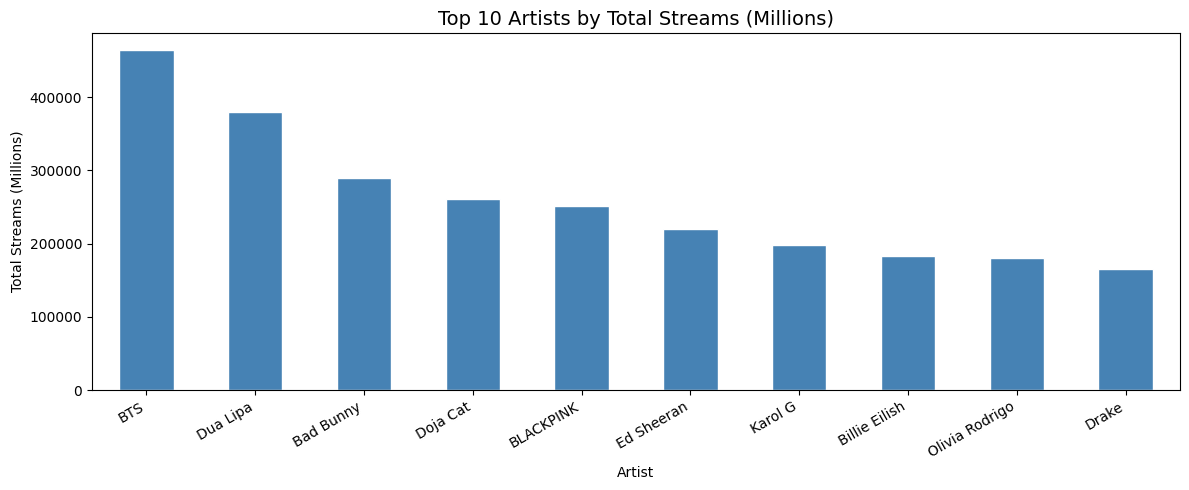

In [49]:
top_artists = (
    df.groupby('artist')['total_streams_millions']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 5))
top_artists.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 10 Artists by Total Streams (Millions)', fontsize=14)
plt.xlabel('Artist')
plt.ylabel('Total Streams (Millions)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Plot 2: Histogram

**When to use:** Understanding the **distribution / shape** of a single numeric column.  
**Question we're answering:** How is skip rate distributed? Is it normally spread or skewed?

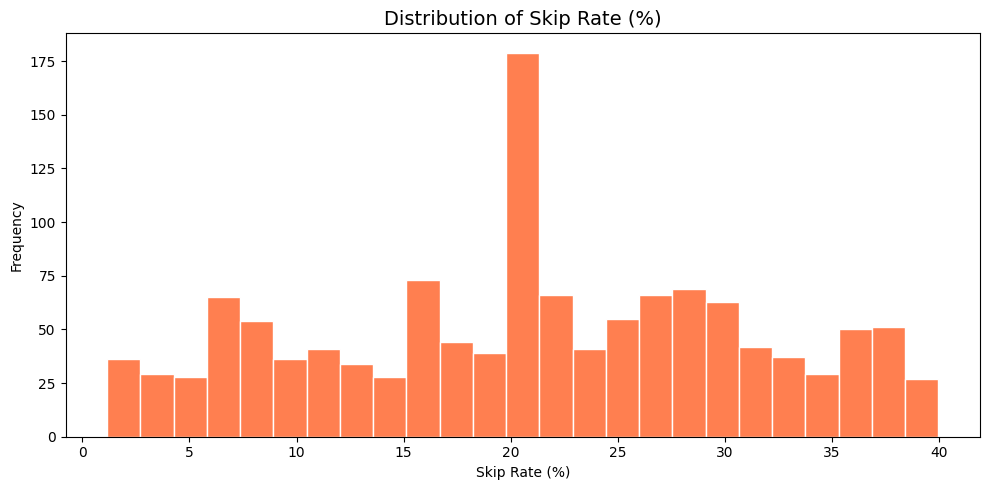

Mean skip rate:  21.04
Median skip rate: 20.85


In [50]:
plt.figure(figsize=(10, 5))
df['skip_rate_pct'].plot(kind='hist', bins=25, color='coral', edgecolor='white')
plt.title('Distribution of Skip Rate (%)', fontsize=14)
plt.xlabel('Skip Rate (%)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print('Mean skip rate: ', round(df['skip_rate_pct'].mean(), 2))
print('Median skip rate:', round(df['skip_rate_pct'].median(), 2))

### Plot 3: Pie Chart

**When to use:** Showing **proportions of a whole** with a small number of categories (< 6).  
**Question we're answering:** What's the split between Free and Premium listeners?

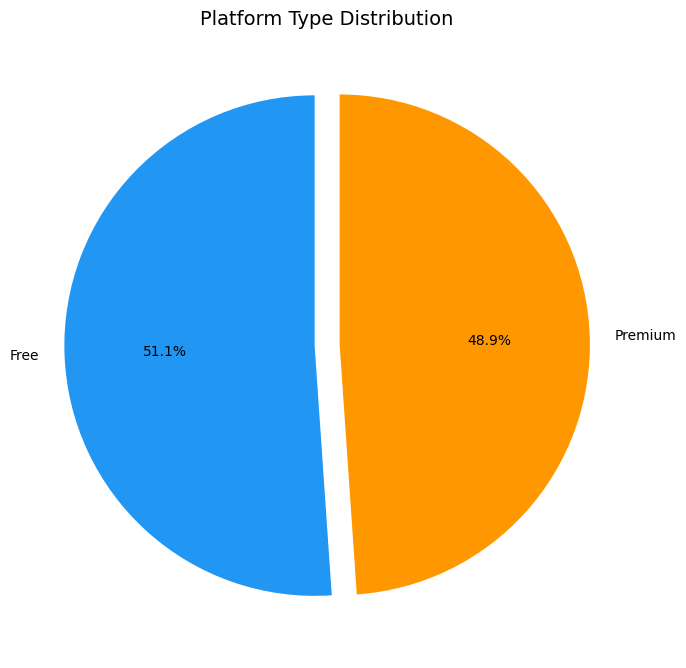

In [51]:
platform_counts = df['platform_type'].value_counts()

plt.figure(figsize=(7, 7))
platform_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['#2196F3', '#FF9800'],
    startangle=90,
    explode=[0.05, 0.05]
)
plt.title('Platform Type Distribution', fontsize=14)
plt.ylabel('')
plt.tight_layout()
plt.show()

### Plot 4: Boxplot

**When to use:** Comparing **distributions across groups** and spotting **outliers**.  
**Question we're answering:** Do different genres have different stream counts? Are there outliers?

**Reading a boxplot:**
- Center line = **median**
- Box edges = **25th and 75th percentile** (IQR)
- Whiskers = typical range
- Dots beyond whiskers = **outliers**

C:\Users\trerr\AppData\Local\Temp\ipykernel_35712\3357272819.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=genre_df, x='genre', y='total_streams_millions', palette='Set2')


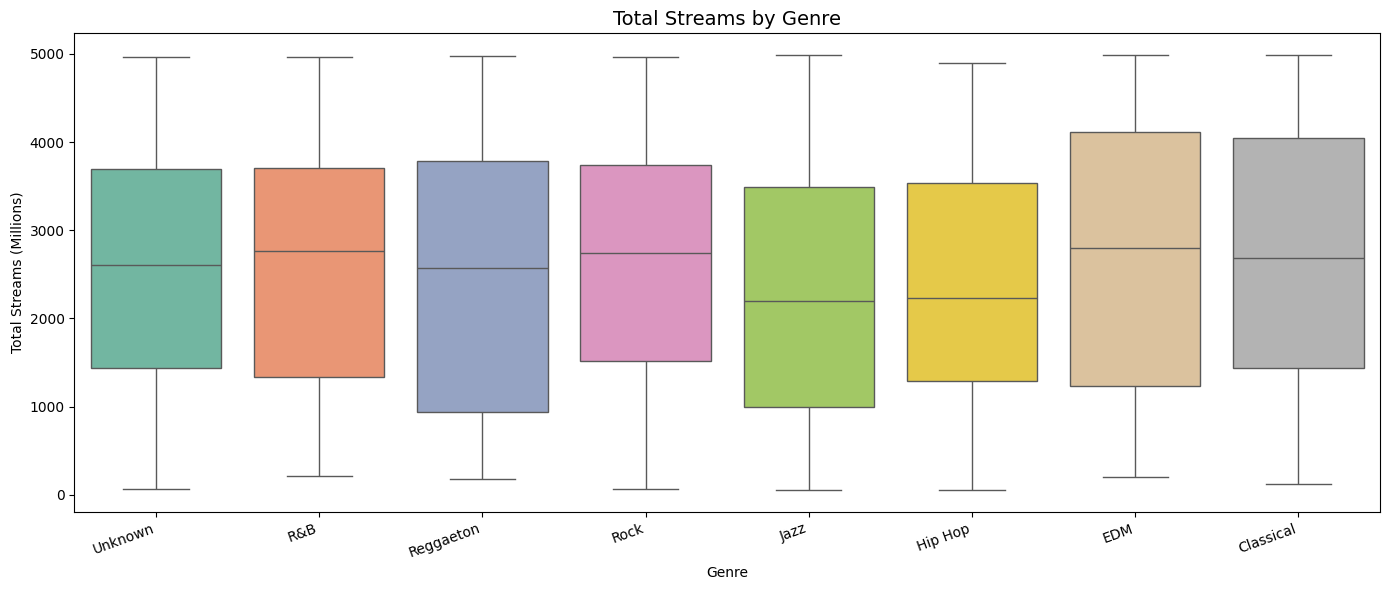

In [52]:
# Filter to main genres so the chart isn't too crowded
top_genres = df['genre'].value_counts().head(8).index
genre_df = df[df['genre'].isin(top_genres)]

plt.figure(figsize=(14, 6))
sns.boxplot(data=genre_df, x='genre', y='total_streams_millions', palette='Set2')
plt.title('Total Streams by Genre', fontsize=14)
plt.xlabel('Genre')
plt.ylabel('Total Streams (Millions)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

### Plot 5: Scatterplot

**When to use:** Exploring the **relationship between two numeric variables**.  
**Question we're answering:** Do artists with more monthly listeners also get more total streams?

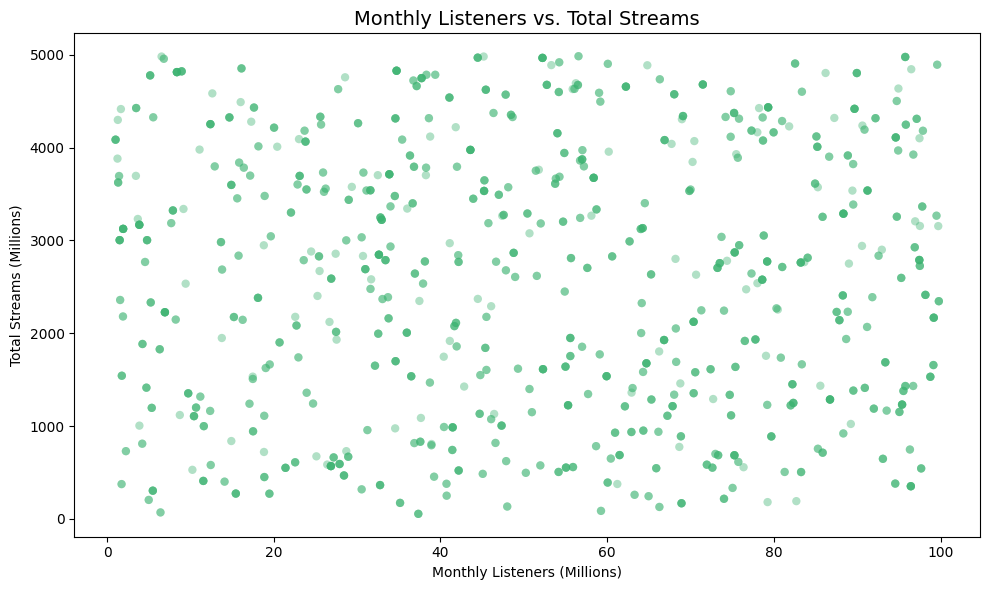

Correlation: -0.011


In [53]:
plt.figure(figsize=(10, 6))
plt.scatter(
    df['monthly_listeners_millions'],
    df['total_streams_millions'],
    alpha=0.4,
    color='mediumseagreen',
    edgecolors='none'
)
plt.title('Monthly Listeners vs. Total Streams', fontsize=14)
plt.xlabel('Monthly Listeners (Millions)')
plt.ylabel('Total Streams (Millions)')
plt.tight_layout()
plt.show()

# Check correlation numerically
corr = df['monthly_listeners_millions'].corr(df['total_streams_millions'])
print(f'Correlation: {corr:.3f}')

### Plot 6: Line Plot

**When to use:** Showing **trends over an ordered sequence** — usually time, but can be any ordering.  
**Question we're answering:** How does average stream duration compare across release years?

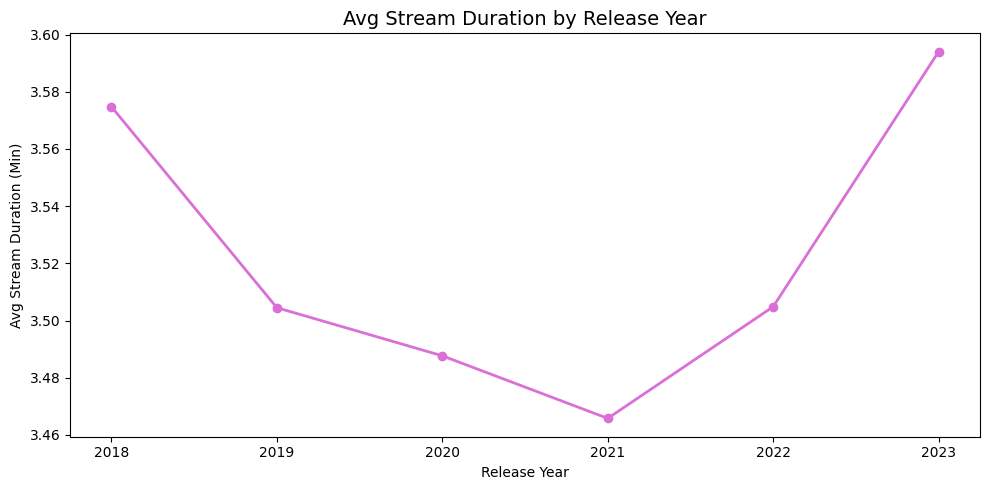

In [54]:
avg_by_year = (
    df.groupby('release_year')['avg_stream_duration_min']
    .mean()
    .sort_index()
)

plt.figure(figsize=(10, 5))
avg_by_year.plot(kind='line', marker='o', color='orchid', linewidth=2)
plt.title('Avg Stream Duration by Release Year', fontsize=14)
plt.xlabel('Release Year')
plt.ylabel('Avg Stream Duration (Min)')
plt.tight_layout()
plt.show()

### Plot 7: Count Plot (Seaborn)

**When to use:** Like a bar chart but directly counts rows per category — no aggregation needed.  
**When to use `hue`:** To compare a second categorical variable side-by-side.  
**Question we're answering:** How many streaming records exist per country? And are they Free or Premium?

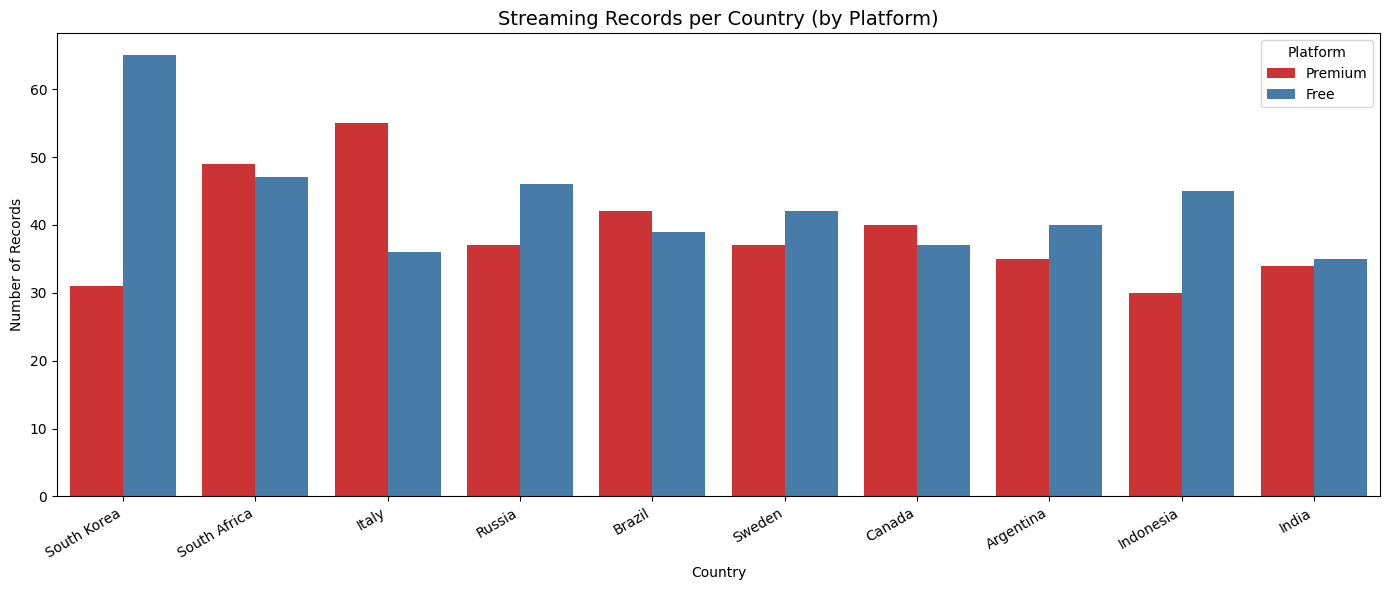

In [55]:
# Top 10 countries by record count
top_countries = df['country'].value_counts().head(10).index
country_df = df[df['country'].isin(top_countries)]

plt.figure(figsize=(14, 6))
sns.countplot(
    data=country_df,
    x='country',
    hue='platform_type',
    palette='Set1',
    order=top_countries
)
plt.title('Streaming Records per Country (by Platform)', fontsize=14)
plt.xlabel('Country')
plt.ylabel('Number of Records')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Platform')
plt.tight_layout()
plt.show()

### Plot 8: Heatmap

**When to use:** Visualizing **correlations between many numeric columns at once**.  
**Reading it:**
- `1.0` (dark red) = perfect positive correlation
- `-1.0` (dark blue) = perfect negative correlation
- `0.0` (white) = no relationship

**Question we're answering:** Which streaming metrics are most related to each other?

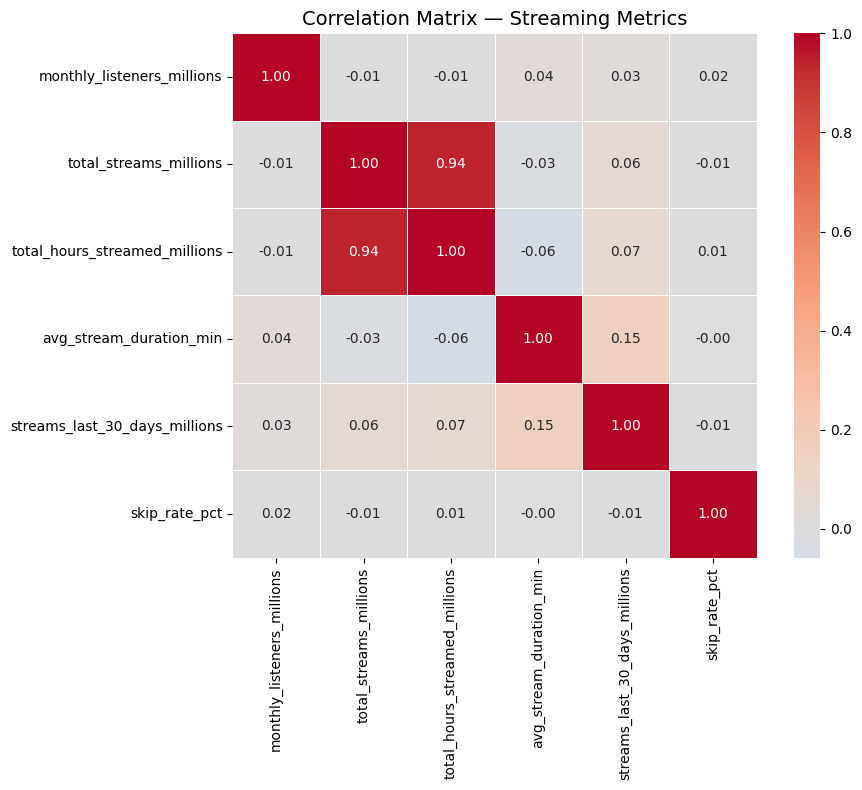

In [56]:
numeric_cols = [
    'monthly_listeners_millions', 'total_streams_millions',
    'total_hours_streamed_millions', 'avg_stream_duration_min',
    'streams_last_30_days_millions', 'skip_rate_pct'
]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Correlation Matrix — Streaming Metrics', fontsize=14)
plt.tight_layout()
plt.show()

---
## Bonus: Putting It Together — Multi-Panel Dashboard

In real projects, you often want several plots on one figure using `plt.subplots()`.

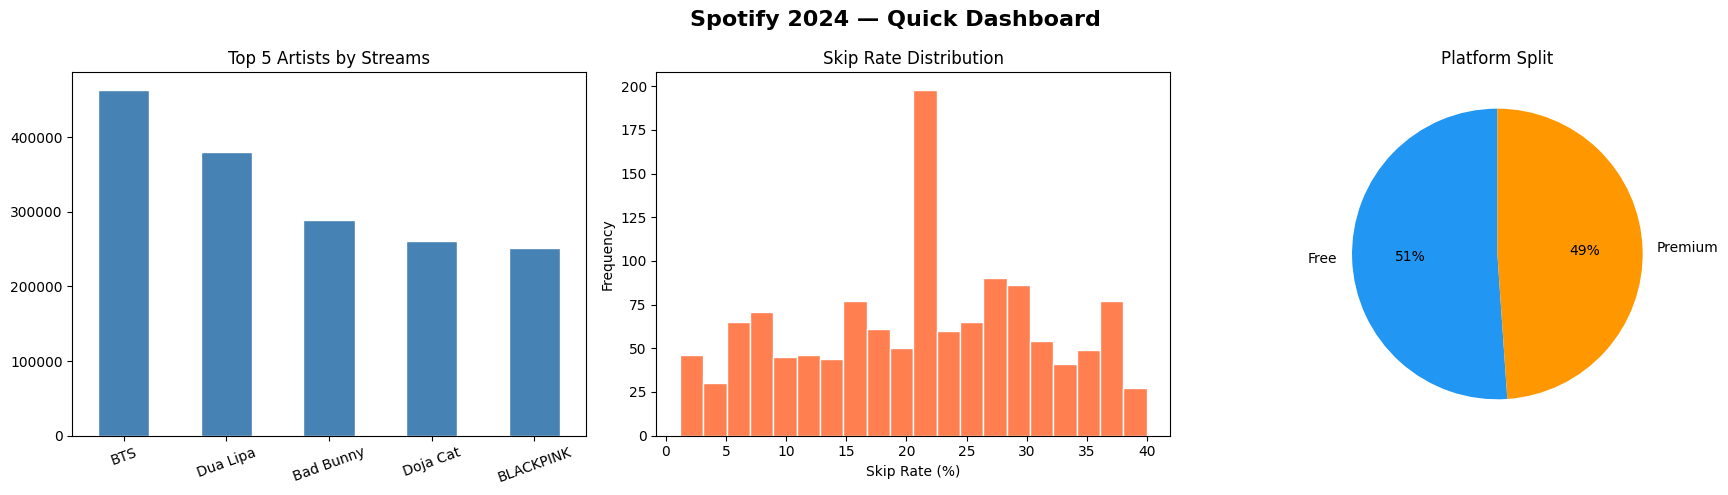

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Spotify 2024 — Quick Dashboard', fontsize=16, fontweight='bold')

# Panel 1: Top 5 Artists
top5 = df.groupby('artist')['total_streams_millions'].sum().sort_values(ascending=False).head(5)
top5.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Top 5 Artists by Streams')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)

# Panel 2: Skip Rate Distribution
df['skip_rate_pct'].plot(kind='hist', bins=20, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Skip Rate Distribution')
axes[1].set_xlabel('Skip Rate (%)')

# Panel 3: Platform split
df['platform_type'].value_counts().plot(
    kind='pie', ax=axes[2], autopct='%1.0f%%',
    colors=['#2196F3', '#FF9800'], startangle=90
)
axes[2].set_title('Platform Split')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

---
## Summary: EDA Best Practices Recap

| Step | Action | Why |
|---|---|---|
| 1 | `.shape`, `.head()`, `.tail()` | Get a feel for size and structure |
| 2 | `.info()` | Check column names, dtypes, and non-null counts |
| 3 | `.describe()` | Summary stats for numeric columns |
| 4 | `.isnull().sum()` | Find and handle missing values |
| 5 | `.duplicated().sum()` | Remove duplicate rows |
| 6 | `.str.strip()` | Fix hidden whitespace (especially before merging!) |
| 7 | `pd.to_numeric()` | Fix columns stored as wrong type |
| 8 | `.value_counts()` | Understand categorical columns |
| 9 | Histograms + Boxplots | Find outliers and understand distributions |
| 10 | Correlation / Heatmap | Find relationships between variables |

## Plot Type Cheat Sheet

| Plot | Use When |
|---|---|
| **Bar Chart** | Comparing counts/values across categories |
| **Histogram** | Understanding the distribution of one numeric variable |
| **Pie Chart** | Showing proportions of a whole (< 6 categories) |
| **Boxplot** | Comparing distributions across groups; spotting outliers |
| **Scatterplot** | Exploring relationship between two numeric variables |
| **Line Plot** | Trends over time or ordered data |
| **Count Plot** | Counting rows per category (no aggregation needed) |
| **Heatmap** | Correlations across many numeric columns at once |